In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
train = pd.read_csv(r"C:\Users\AIML\Desktop\CREDITCARDFRAUDDETECTION\data\fraudTrain.csv")
test = pd.read_csv(r"C:\Users\AIML\Desktop\CREDITCARDFRAUDDETECTION\data\fraudTest.csv")

print(train.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suite 393  ...  48

In [3]:
print(train.info())
print(train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [4]:
print(train.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


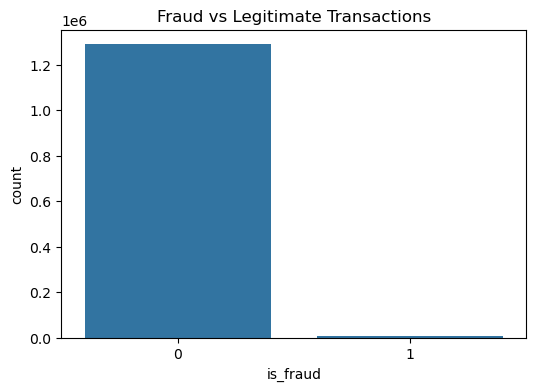

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=train)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

In [6]:
train = train.drop(columns=[
    'trans_date_trans_time',
    'cc_num',
    'merchant',
    'first',
    'last',
    'street',
    'city',
    'state',
    'dob',
    'trans_num'
])

test = test.drop(columns=[
    'trans_date_trans_time',
    'cc_num',
    'merchant',
    'first',
    'last',
    'street',
    'city',
    'state',
    'dob',
    'trans_num'
])

In [7]:
le = LabelEncoder()

train['category'] = le.fit_transform(train['category'])
train['gender'] = le.fit_transform(train['gender'])
train['job'] = le.fit_transform(train['job'])

test['category'] = le.fit_transform(test['category'])
test['gender'] = le.fit_transform(test['gender'])
test['job'] = le.fit_transform(test['job'])

In [8]:
X_train = train.drop("is_fraud", axis=1)
y_train = train["is_fraud"]

X_test = test.drop("is_fraud", axis=1)
y_test = test["is_fraud"]

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.9955121203341977


In [11]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.9875350671832347


In [12]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.997502334813098


In [13]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.77      0.51      0.61      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.75      0.80    555719
weighted avg       1.00      1.00      1.00    555719



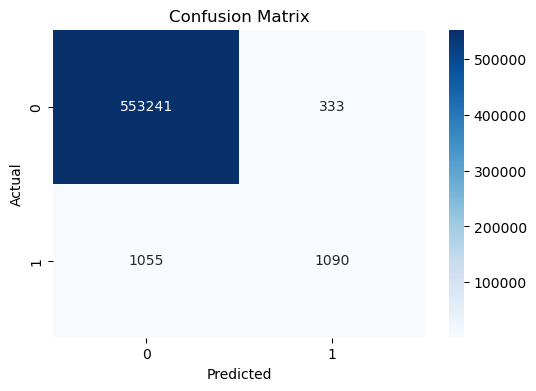

In [14]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

importance = model.feature_importances_

features = train.drop("is_fraud", axis=1).columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)

plt.title("Feature Importance")
plt.show()

In [ ]:
sample = X_test[0].reshape(1,-1)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Legitimate Transaction")